In [ ]:
################################## Logistic Regression #######################################

In [ ]:
#1. Data Exploration:

In [1]:
#--------> a. Load the dataset and perform exploratory data analysis (EDA).

import pandas as pd
df = pd.read_csv("diabetes.csv")
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [4]:
#--------> b. Examine the features, their types, and summary statistics.

print("---------------Dataset Types---------------------------") # examins types
df.info()

print("\n-------------------Summary Statistics--------------------------")# examins summary statistics.
print(df.describe())

print("\n-----------------Missing Values-------------------------------")# examins features
print(df.isnull().sum())

---------------Dataset Types---------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB

-------------------Summary Statistics--------------------------
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.0000

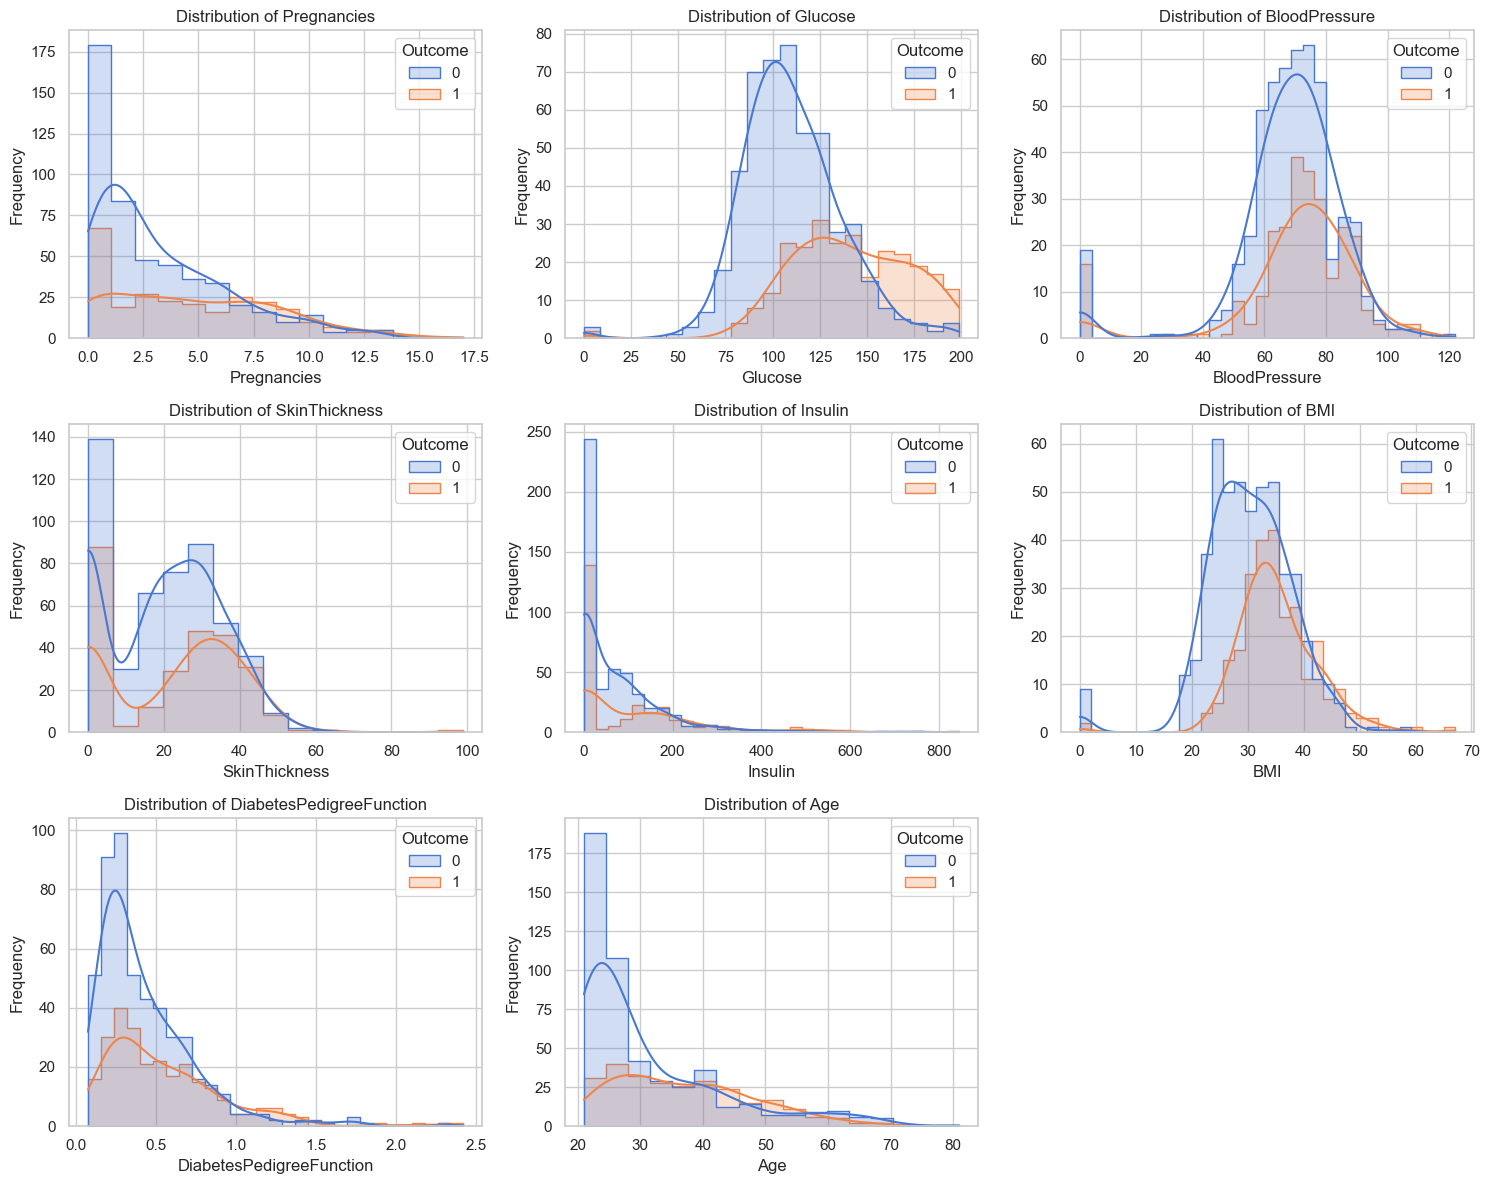

In [6]:
#-------->c. Create visualizations such as histograms, box plots, or pair plots to visualize the distributions and relationships between features.

# >>> histogram

import seaborn as sns
import matplotlib.pyplot as plt

# Sets the style 
sns.set_theme(style="whitegrid")

#creates grid 
features = df.columns[:-1]  # Selects all columns except 'Outcome'
plt.figure(figsize=(15, 12))

for i, col in enumerate(features, 1):
    plt.subplot(3, 3, i)
    # Used hue to separate data by the Outcome (0 or 1)
    sns.histplot(data=df, x=col, hue="Outcome", kde=True, element="step", palette="muted")
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

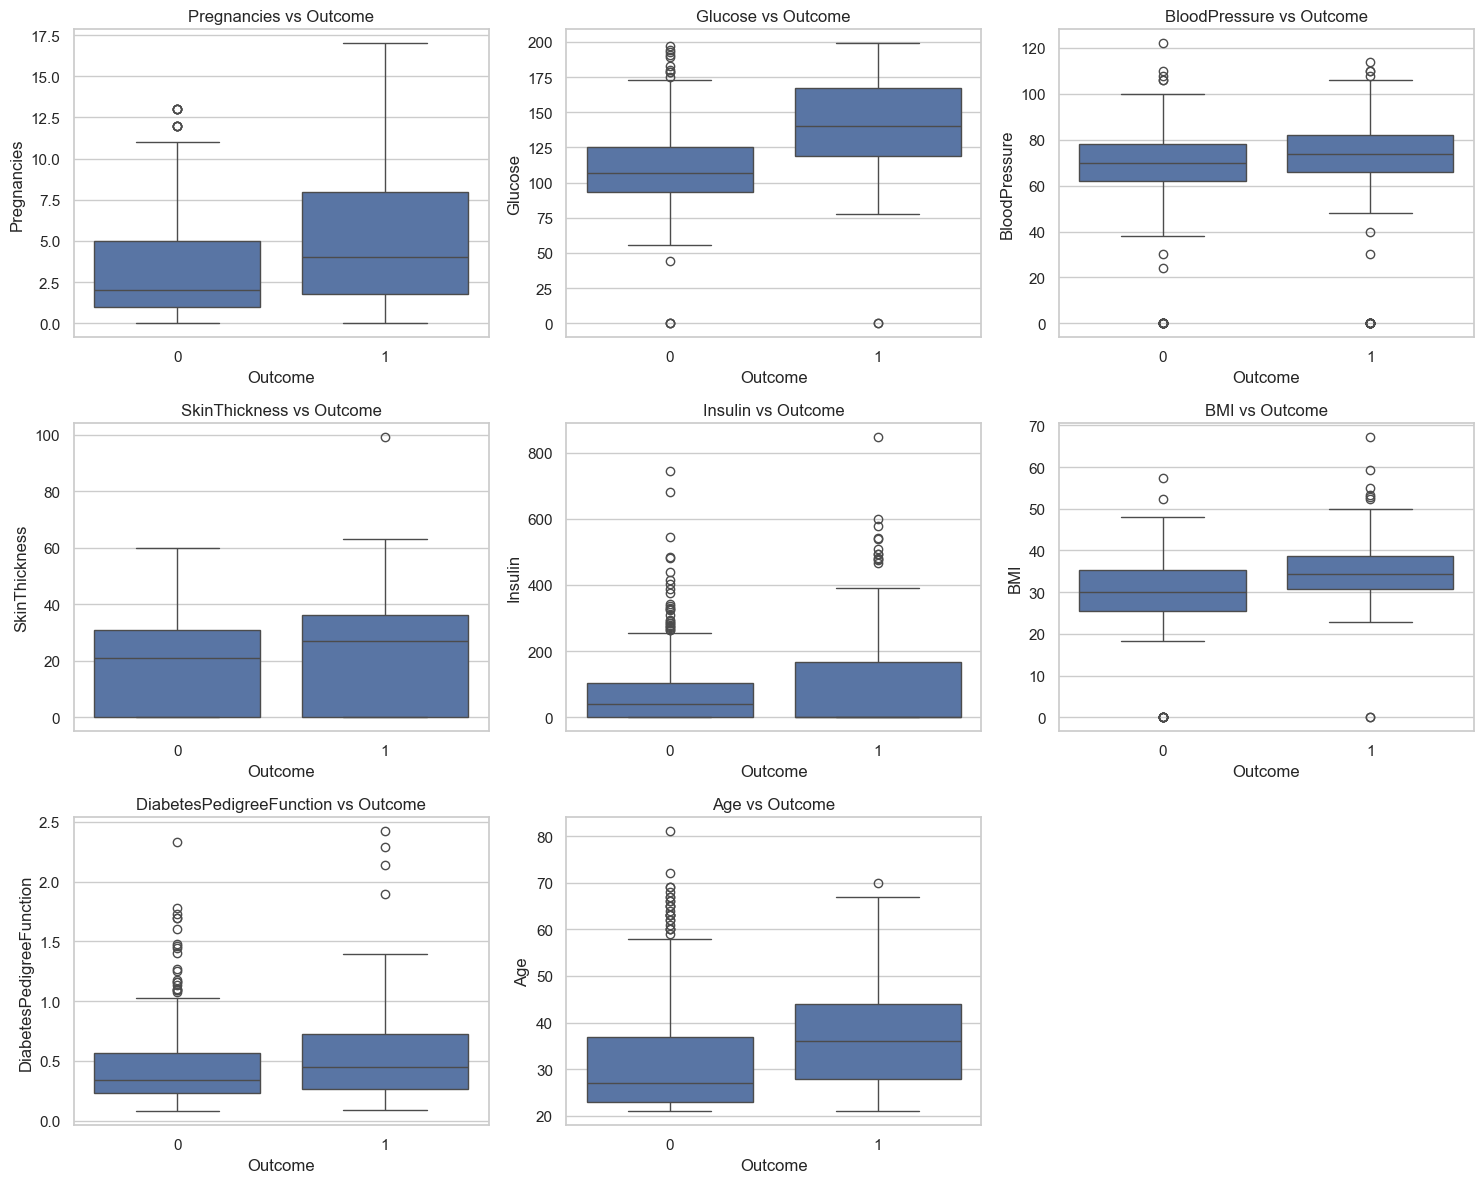

In [7]:
# >>> boxplot

plt.figure(figsize=(15, 12))
features = df.columns[:-1] # All except Outcome
for i, col in enumerate(features, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(x='Outcome', y=col, data=df)
    plt.title(f'{col} vs Outcome')

plt.tight_layout()
plt.show()


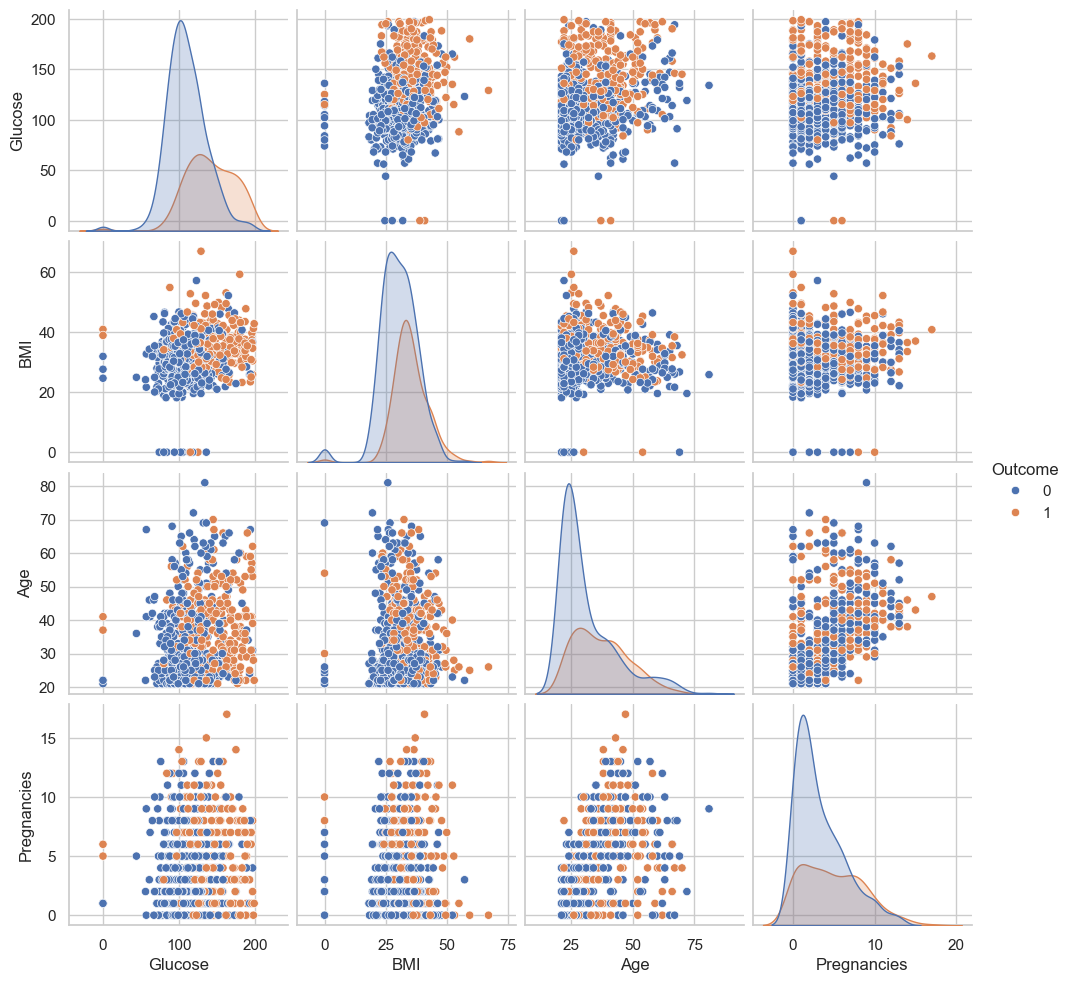

In [8]:
# >>> pairplot

#I have chossed only relevant features 
selected_cols = ['Glucose', 'BMI', 'Age', 'Pregnancies', 'Outcome']
pair_plot = sns.pairplot(df[selected_cols], hue='Outcome', diag_kind='kde')

---> Analyze any patterns or correlations observed in the data.

* Primary Predictors: Glucose has the strongest correlation with diabetes (~0.47). Higher glucose levels clearly shift toward a positive outcome.

* Secondary Predictors: BMI and Age show moderate positive correlations; as these values increase, the likelihood of diabetes increases.

* Feature Links: Age and Pregnancies are moderately linked (~0.54), suggesting they provide overlapping information to the model.

* Data Issues: Columns like BMI and BloodPressure contain zeros, which are biologically impossible and represent missing values that need cleaning.

* Outliers: Insulin and DiabetesPedigreeFunction have extreme high values (outliers) that could skew the logistic regression curve.

* Complexity: Features like BloodPressure overlap heavily between classes, meaning no single feature is a perfect predictor on its own.

In [ ]:
#2. Data Preprocessing:

In [9]:
#--------> a. Handle missing values (e.g., imputation).

import numpy as np

# Define columns where there are 0
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Replaces 0 with NaN 
df[cols_with_zeros] = df[cols_with_zeros].replace(0, np.nan)

# Impute using Median (chosen because it is robust to outliers)
for col in cols_with_zeros:
    df[col] = df[col].fillna(df[col].median())

# Verifies no missing values remain
print(df.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [10]:
#missing values are filled
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


In [11]:
#--------> b. Encode categorical variables.

# Checks for categorical variables (Object types)
categorical_cols = df.select_dtypes(include=['object']).columns

if len(categorical_cols) == 0:
    print("No categorical variables found. All features are already numerical.")
else:
    print(f"Categorical variables to encode: {categorical_cols}")

No categorical variables found. All features are already numerical.


In [ ]:
# 3. Model Building:

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#Separates Features (X) and Target (y)
# We drop 'Outcome' because it model predicts the answer
X = df.drop('Outcome', axis=1)
y = df['Outcome']

#Splits into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Feature Scaling
scaler = StandardScaler()

# Fit on training data and transform both sets
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Data successfully split and scaled.")
print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Data successfully split and scaled.
Training samples: 614
Testing samples: 154


In [18]:
#--------> a. Build a logistic regression model using appropriate libraries (e.g., scikit-learn).

In [19]:
from sklearn.linear_model import LogisticRegression 
model = LogisticRegression()


In [20]:
#-------->b. Train the model using the training data.

model.fit(X_train, y_train)
print("Model Building and Training complete.")

Model Building and Training complete.


In [ ]:
#4. Model Evaluation:

In [21]:
#-------->a. Evaluate the performance of the model on the testing data using accuracy, precision, recall, F1-score, and ROC-AUC score

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

#Gets predictions from the model
y_pred = model.predict(X_test)

#Gets probabilities for ROC-AUC
y_prob = model.predict_proba(X_test)[:, 1]

#Calculates Metrics
metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1-Score": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_prob)
}

#Displays results
for metric, value in metrics.items():
    print(f"{metric}: {value:.4f}")

Accuracy: 0.7532
Precision: 0.6667
Recall: 0.6182
F1-Score: 0.6415
ROC-AUC: 0.8228


Area Under Curve Score : 0.82


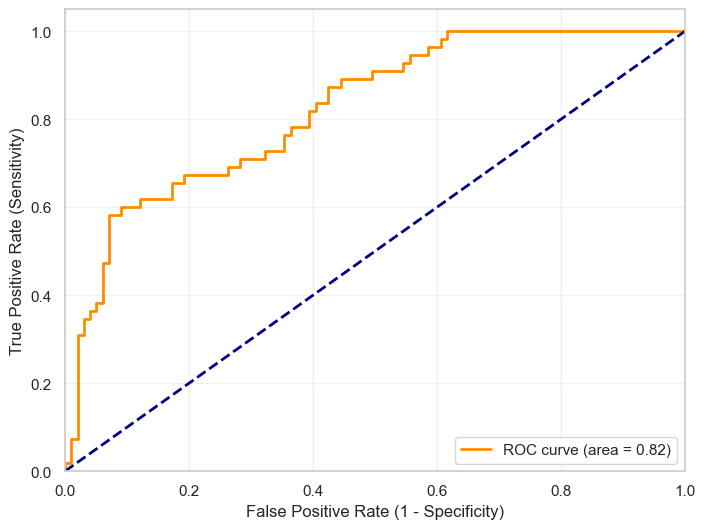

In [27]:
#-------->Visualize the ROC curve

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

#Gets the probabilities for the positive class (Diabetes)
y_prob = model.predict_proba(X_test)[:, 1]

#Calculates the False Positive Rate (fpr) and True Positive Rate (tpr)

#dummy variable to store roc value
fpr, tpr, dummy = roc_curve(y_test, y_prob)


#Calculates the Area Under the Curve (AUC)
AUC = roc_auc_score(y_test, y_prob)
print("Area Under Curve Score :" , np.round(AUC,2))

#plotting
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Diagonal line (Random guess)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
# plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

1. The Navy Line (Diagonal) :
           * The "Random Guess" baseline representing an AUC of 0.50.
           * It represents a model with zero predictive power; any curve above this line proves your model is better than a coin flip.

2. The Orange Line (Curve)
         * The actual performance of your Logistic Regression model.
         *  Its "bow" toward the top-left corner shows how well the model separates sick patients from healthy ones as you change the diagnostic                           threshold.

3. The AUC Score (0.82)
        *  The "Area Under the Curve," which provides a single performance grade from 0 to 1.
        *  A score of 0.82 means there is an 82% chance the model correctly distinguishes a diabetic patient from a healthy one, which is considered                "Good/Excellent" discrimination.

In [ ]:
#5. Interpretation:

In [28]:
#-------->a. Interpret the coefficients of the logistic regression model.

# Create a DataFrame to see feature names next to their coefficients
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_[0]})
print(coef_df.sort_values(by='Coefficient', ascending=False))

                    Feature  Coefficient
1                   Glucose     1.102682
5                       BMI     0.688839
7                       Age     0.392410
0               Pregnancies     0.222978
6  DiabetesPedigreeFunction     0.203635
3             SkinThickness     0.068836
4                   Insulin    -0.138252
2             BloodPressure    -0.151540


1. Positive Coefficients
         * As these values (like Glucose) increase, the mathematical probability of a "Diabetic" outcome increases.
         * These are the Risk Factors; the higher the number, the stronger that feature pushes the model toward a positive diagnosis.

2. Negative Coefficients
         * As these values increase, the mathematical probability of being classified as "Diabetic" decreases.
         * These are the Protective Factors; they act as "weights" that pull the model's prediction toward the "Healthy" class.

3. Magnitude (Absolute Size)
         * The further a coefficient is from zero (positive or negative), the more influence that feature has on the prediction.
         * Since your data is scaled, you can directly compare them; the largest number represents the most important feature in your dataset.

In [32]:
#-------->b. Discuss the significance of features in predicting the target variable (survival probability in this case).

#Extracts feature names and their coefficient values
significance_df = pd.DataFrame({
    'Feature': X.columns, 
    'Coefficient': model.coef_[0]
})

#Uses absolute values to rank 'importance'
significance_df['Significance_Score'] = significance_df['Coefficient'].abs()

#Sorts from most significant to least significant
significance_df = significance_df.sort_values(by='Significance_Score', ascending=False)

print(significance_df[['Feature', 'Significance_Score']])

                    Feature  Significance_Score
1                   Glucose            1.102682
5                       BMI            0.688839
7                       Age            0.392410
0               Pregnancies            0.222978
6  DiabetesPedigreeFunction            0.203635
2             BloodPressure            0.151540
4                   Insulin            0.138252
3             SkinThickness            0.068836


Glucose (1.10) and BMI (0.68) have the highest scores, making them the primary "decision-makers" for this model.

In [33]:
# 6. Deployment with Streamlit:

import joblib
# This "exports" your model into a file
joblib.dump(model, 'diabetes_model.pkl') #freezes the model

['diabetes_model.pkl']